# Week 5: Model a magnetic dipole from surface data

**Practical exercise, 25–35 minutes.** Use projection, superposition, and residuals to estimate a dipole and one additional field component. No spherical-harmonic software or theory is required; optional investigations can take longer.

## Data and physical setting

The CSV file contains 2,048 model-generated values of Earth's outward radial magnetic field. They come from IGRF-14, a reference model based on observations, using degrees 1–13 for epoch 2025.0. The values are calculated assuming a spherical Earth with radius $a=6371.2\,\mathrm{km}$; they are not direct measurements.

The columns are geographic colatitude `theta_geo_deg`, east longitude `longitude_east_deg`, geocentric latitude `latitude_geocentric_deg`, outward radial field `Br_uT` in microtesla, and solid-angle weight `weight_sr`. Colatitude is measured from geographic north; latitude is $90^\circ-\theta_g$ and is not geodetic latitude. The grid uses 32 Gauss–Legendre colatitudes and 64 evenly spaced longitudes. The weights represent each sample's share of the sphere and sum to $4\pi$ steradians. Use them for surface sums: do not multiply by $\sin\theta_g$ again or take a plain average.

The accompanying metadata gives the epoch, reference radius, coefficient provenance, and unit vector along the reference dipole moment. Its direction is supplied for the main exercise, so estimate the strength. Geographic $x$ points to latitude $0^\circ$, longitude $0^\circ$; $y$ points to latitude $0^\circ$, longitude $90^\circ\mathrm{E}$ ; and $z$ points to geographic north. The data and metadata files must remain beside this notebook. No answer coefficients are included.

In [10]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

folder = Path('.')  # run with this notebook folder as the working directory
samples = np.genfromtxt(folder / 'igrf14_surface_2025.csv', delimiter=',', names=True)
metadata = json.loads((folder / 'metadata.json').read_text())
theta = np.deg2rad(samples['theta_geo_deg'])
phi = np.deg2rad(samples['longitude_east_deg'])
br = samples['Br_uT']
w = samples['weight_sr']
mhat = np.array(metadata['dipole_axis_unit_vector_xyz'])
print('Number of values:', br.size)
print('Sum of weights:', w.sum(), 'Expected:', 4*np.pi)


Number of values: 2048
Sum of weights: 12.56637061436032 Expected: 12.566370614359172


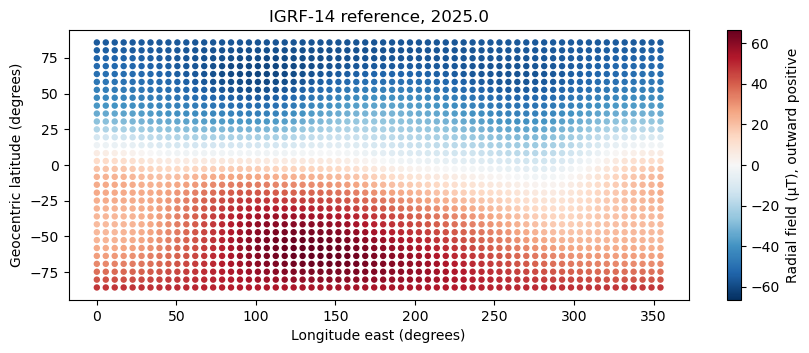

In [11]:
def map_values(values, title, limit=None):
    if limit is None:
        limit = np.max(np.abs(values))
    fig, ax = plt.subplots(figsize=(10, 3.5))
    points = ax.scatter(samples['longitude_east_deg'], samples['latitude_geocentric_deg'],
                        c=values, cmap='RdBu_r', vmin=-limit, vmax=limit, s=13)
    ax.set(xlabel='Longitude east (degrees)', ylabel='Geocentric latitude (degrees)', title=title)
    fig.colorbar(points, ax=ax, label='Radial field (µT), outward positive')
    plt.show()

map_values(br, 'IGRF-14 reference, 2025.0')


## 1. Build the dipole pattern

Convert the geographic angles to radians and construct the outward unit vector

$$
\hat r=(\sin\theta_g\cos\varphi,\ \sin\theta_g\sin\varphi,\ \cos\theta_g).
$$

Use the supplied unit vector of the dipole moment, $\hat m$, to calculate the dipole pattern

$$
f_d=\hat m\cdot\hat r=\cos\theta_m.
$$

Explain why geographic colatitude $\theta_g$ and angle from the dipole axis $\theta_m$ are different. State the sign of $f_d$ at each end of the magnetic axis. For a centered dipole, the radial field at the sphere is

$$
B_{r,d}=\alpha f_d,\qquad \alpha=\frac{2C}{a^3},\qquad C=\frac{\mu_0|\vec m|}{4\pi}.
$$

The pattern is a cosine: it equals $+1$ along $\hat m$, $-1$ in the opposite direction, and zero perpendicular to the axis.

In [12]:
# Build one outward unit vector per sample, with shape (number_of_samples, 3).
rhat = np.column_stack((np.sin(theta) * np.cos(phi),
                        np.sin(theta) * np.sin(phi),
                        np.cos(theta)))

# Obtain one value per surface point (number_of_samples,)
fd = rhat @ mhat  # one value per surface point

Geographic colatitude $\theta_g$ is measured from Earth's north pole. The angle $\theta_m$ is measured from the tilted magnetic axis, so the two angles are generally different. The supplied axis points toward the southern magnetic pole, where $f_d=+1$; at the opposite pole, $f_d=-1$.

## 2. Project the surface field onto the dipole pattern

The surface inner product is $\langle u,v\rangle=\int uv\,d\Omega$, where $d\Omega=\sin\theta_g\,d\theta_g\,d\varphi$. Approximate it with the supplied weights:

$$
\alpha=\frac{\langle B_r,f_d\rangle}{\langle f_d,f_d\rangle}
\simeq\frac{\sum_i w_i B_{r,i}f_{d,i}}{\sum_i w_i f_{d,i}^2}.
$$

Calculate $\alpha$ in $\mu\mathrm{T}$. Explain why the formula divides by the squared size of the pattern, and compare this with finding a Fourier coefficient. If you reverse the chosen axis, how do $f_d$ and $\alpha$ change? Does the fitted field change?

Use $\alpha$ to find $C$ in T $\mathrm{m}^3$, and optionally the moment magnitude, $A$, in $\mathrm{m}^2$. Convert $\alpha$ from $\mu\mathrm{T}$ to T and $a=6371.2\,\mathrm{km}$ to metres first. Since $C$ is a magnitude, use $C=|\alpha|a^3/2$ if $\alpha$ is negative. Is $\alpha$ the radial field strength at the magnetic pole or equator? For the moment magnitude, use $|\vec m|=4\pi C/\mu_0$.

In [17]:
# Weighted least-squares projection onto the supplied dipole pattern.
alpha = np.sum(w * br * fd) / np.sum(w * fd**2)  # µT

# Convert the radial polar amplitude and reference radius to SI units.
a_m = metadata['radius_km'] * 1e3
alpha_T = alpha * 1e-6
C = abs(alpha_T) * a_m**3 / 2  # T m^3
mu0 = 4 * np.pi * 1e-7
moment_magnitude = 4 * np.pi * C / mu0  # A m^2

print(f'alpha = {alpha:.6f} µT (signed for the supplied axis)')
print(f'C = {C:.6e} T m^3')
print(f'|m| = {moment_magnitude:.6e} A m^2')
print('alpha is the radial polar amplitude; the radial equatorial field is zero.')

alpha = 59.466731 µT (signed for the supplied axis)
C = 7.689671e+15 T m^3
|m| = 7.689671e+22 A m^2
alpha is the radial field at the magnetic poles; it is zero at the magnetic equator.


The denominator, $\langle f_d,f_d\rangle$, accounts for the size of the pattern; this is like the normalization used to find a Fourier coefficient. Reversing the axis changes the signs of both $f_d$ and $\alpha$, so the fitted field $\alpha f_d$ stays the same. Here $\alpha=59.466731\,\mu\mathrm{T}$. It is the radial field strength at the magnetic pole; the dipole's radial field is zero at the magnetic equator. The inferred magnitudes are $C=7.689671\times10^{15}\,\mathrm{T\,m^3}$ and $|\vec m|=7.689671\times10^{22}\,\mathrm{A\,m^2}$.

## 3. What does the dipole model leave out?

Calculate the fitted radial field $B_{r,d}=\alpha f_d$ and residual $B_r-B_{r,d}$. Plot the observed field and fitted field with the same colour limits, then plot the residual with its own scale so its structure is visible. Calculate the area-weighted RMS residual,

$$
\mathrm{RMS}(q)=\sqrt{\frac{\sum_i w_i q_i^2}{\sum_i w_i}}.
$$

Verify that the residual inner product with $f_d$ is approximately zero. Does that imply that the residual vanishes everywhere? Compare fitting a coefficient to checking the model at one location: projection fits the full surface in a weighted least-squares sense, but does not require the dipole to meet the data at every point.

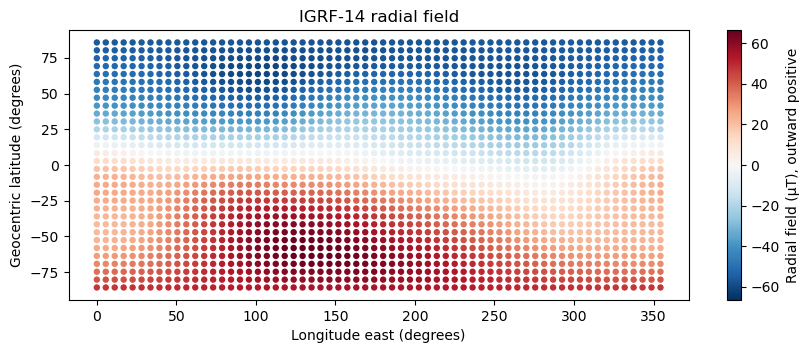

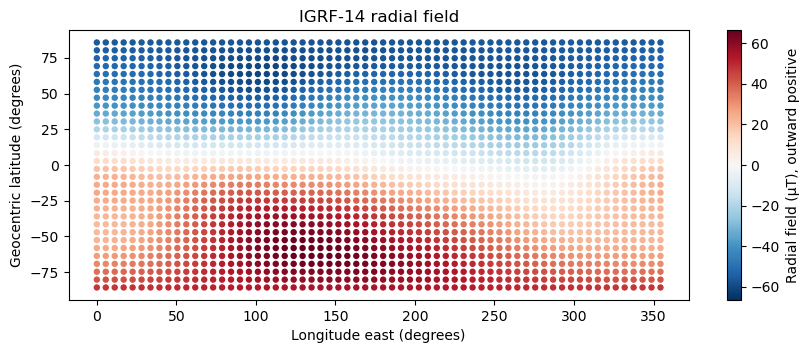

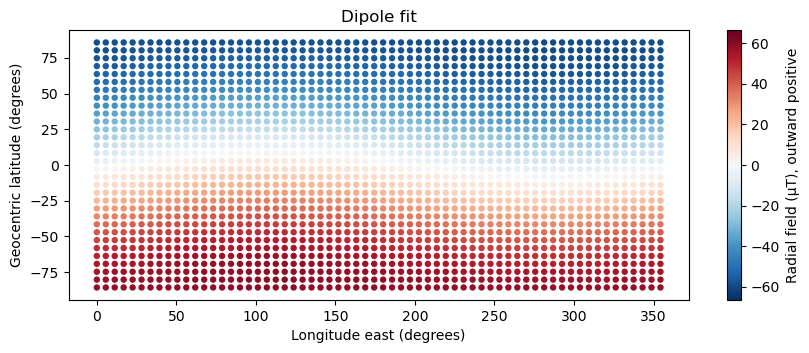

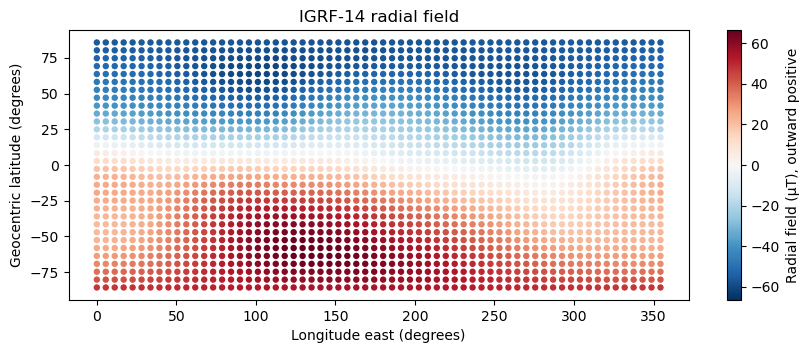

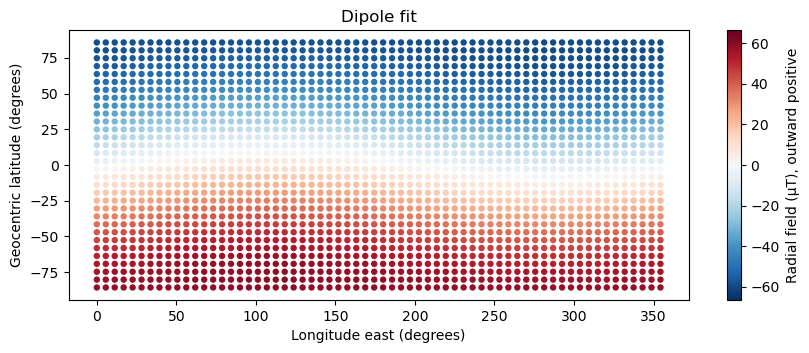

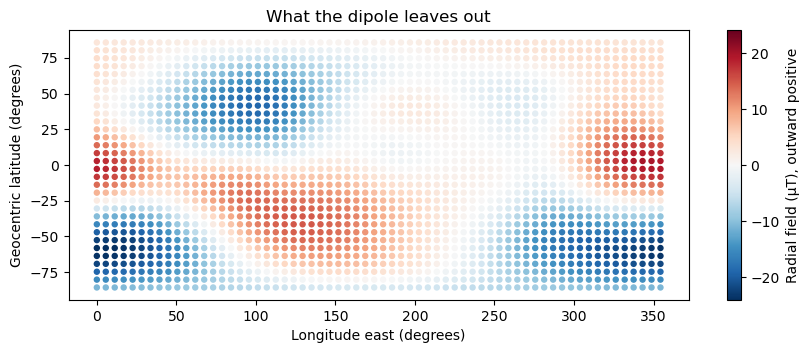

Dipole-only weighted RMS = 8.938173 µT
Weighted overlap of residual with fd = 3.286e-14 µT sr


In [18]:
fit_d = alpha * fd
residual_d = br - fit_d
weighted_rms = lambda values: np.sqrt(np.sum(w * values**2) / np.sum(w))
rms_d = weighted_rms(residual_d)
residual_d_projection = np.sum(w * residual_d * fd)

shared_limit = max(np.max(np.abs(br)), np.max(np.abs(fit_d)))
map_values(br, 'IGRF-14 radial field', limit=shared_limit)
map_values(fit_d, 'Best-fit centered dipole', limit=shared_limit)
map_values(residual_d, 'Dipole residual')

print(f'Dipole-only weighted RMS = {rms_d:.6f} µT')
print(f'Weighted residual projection onto fd = {residual_d_projection:.3e} µT sr')

The dipole-only residual has a weighted RMS of $8.938173\,\mu\mathrm{T}$. Its weighted inner product with $f_d$ is zero to numerical precision. This is expected: changing the dipole strength cannot improve the fit any further. It does not mean the residual is zero everywhere; the remaining field still varies across the surface.

## 4. Add an aligned axial quadrupole

Use the same magnetic axis to define a second pattern, the so-called "aligned axial quadrupole":

$$
f_q=\frac{3f_d^2-1}{2},\qquad B_r\approx\alpha f_d+\beta f_q.
$$

Check whether $\sum_i w_i f_{d,i}f_{q,i}$ is close to zero. Explain the symmetry: at opposite points, the dipole pattern changes sign, but the quadrupole pattern keeps the same value. Project both the data and the dipole residual onto $f_q$ to find $\beta$. Why should these two estimates agree? Plot the residual after adding the quadrupole and compare its weighted RMS with the dipole-only value.

For the potential used in class, $\Psi_q=D f_q/r^3$, calculate $D=\beta a^4/3$ in T m$^4$. Convert $\beta$ and $a$ to SI units first. Use the sign of $\beta$ to explain how the quadrupole changes the field at the two ends of the magnetic axis.

This fits one axisymmetric quadrupole pattern about the supplied magnetic axis. It is not the full degree-two field, which has five independent patterns, and it is not generally the geographic-axis IGRF coefficient $g_2^0$. Other parts of the field are therefore expected to remain in the residual.

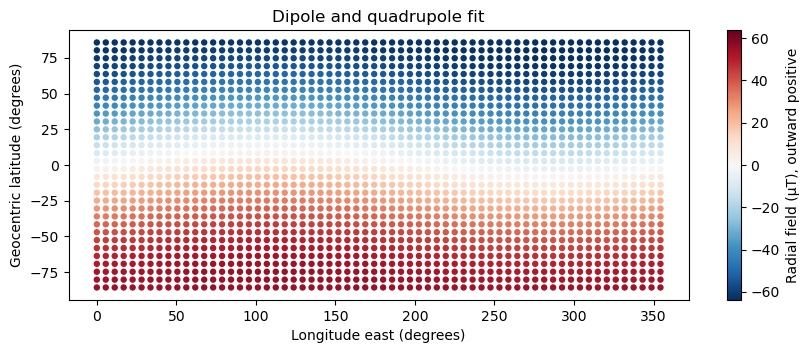

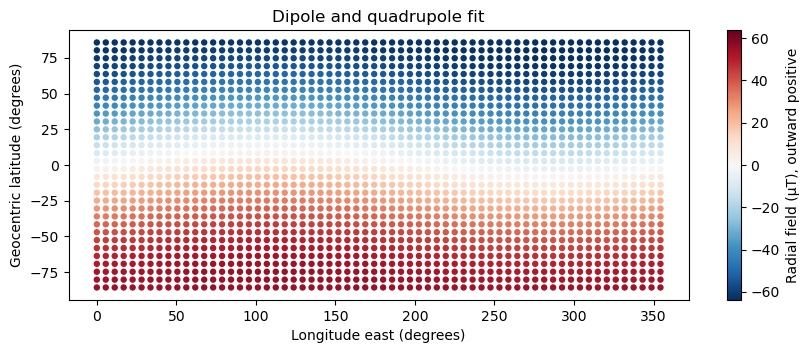

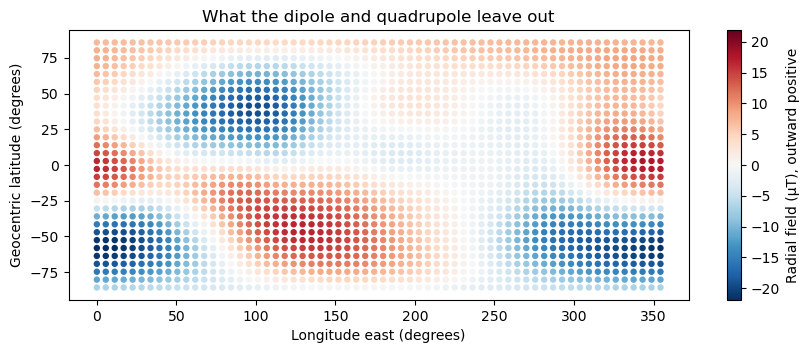

Weighted overlap of dipole and quadrupole patterns = -2.723e-12 sr
beta from full field = -4.258652 µT
beta from dipole residual = -4.258652 µT
D = -2.339030e+21 T m^4
Dipole-only weighted RMS = 8.938173 µT
Dipole and quadrupole weighted RMS = 8.732910 µT
New residual overlaps: fd=-1.157e-11, fq=1.620e-10 µT sr
Negative beta reduces the outward field at both magnetic poles relative to the dipole-only fit.


In [19]:
fq = (3 * fd**2 - 1) / 2
weighted_dq = np.sum(w * fd * fq)
beta = np.sum(w * br * fq) / np.sum(w * fq**2)  # µT
beta_from_residual = np.sum(w * residual_d * fq) / np.sum(w * fq**2)  # µT

D = (beta * 1e-6) * a_m**4 / 3  # T m^4
fit_dq = fit_d + beta * fq
residual_dq = br - fit_dq
rms_dq = weighted_rms(residual_dq)
residual_dq_d_projection = np.sum(w * residual_dq * fd)
residual_dq_q_projection = np.sum(w * residual_dq * fq)

map_values(fit_dq, 'Dipole plus aligned axial quadrupole')
map_values(residual_dq, 'Residual after dipole and quadrupole')

print(f'Weighted fd-fq inner product = {weighted_dq:.3e} sr')
print(f'beta from original field = {beta:.6f} µT')
print(f'beta from dipole residual = {beta_from_residual:.6f} µT')
print(f'D = {D:.6e} T m^4')
print(f'Dipole-only weighted RMS = {rms_d:.6f} µT')
print(f'Dipole + quadrupole weighted RMS = {rms_dq:.6f} µT')
print(f'New residual projections: fd={residual_dq_d_projection:.3e}, fq={residual_dq_q_projection:.3e} µT sr')
if beta > 0:
    print('Positive beta adds outward radial field at both magnetic-axis ends relative to the dipole-only model.')
else:
    print('Negative beta subtracts outward radial field at both magnetic-axis ends relative to the dipole-only model.')

At opposite points, $f_d$ changes sign while $f_q$ does not. Their weighted inner product over the full sphere is therefore zero. The fitted quadrupole coefficient is $\beta=-4.258652\,\mu\mathrm{T}$, whether calculated from the data or from the dipole residual. The negative sign lowers the outward field at the $+\hat m$ end and makes the inward field stronger at the opposite end. Adding this pattern slightly lowers the weighted RMS, from $8.938173$ to $8.732910\,\mu\mathrm{T}$. Other field patterns remain. The recovered value is $D=-2.339030\times10^{21}\,\mathrm{T\,m^4}$.

## Optional investigations

### Estimate the dipole direction too

Instead of using the supplied axis, use the three geographic patterns

$$
f_x=\sin\theta_g\cos\varphi,\qquad f_y=\sin\theta_g\sin\varphi,\qquad f_z=\cos\theta_g.
$$

Project $B_r$ onto each pattern using the full-sphere weights, with the appropriate pattern norm in each denominator. Assemble the three coefficients into a vector. Its length is the dipole polar amplitude; its unit direction estimates the moment direction. Compare that direction with the metadata. This recovers the full centred tilted dipole from radial field alone.

### Use data from only part of Earth

Keep only samples in the geographic northern hemisphere. Recheck pattern orthogonality and compare independent projections with a simultaneous weighted least-squares fit to your chosen patterns. Explain why full-sphere orthogonality does not guarantee independent coefficient recovery from incomplete or unevenly weighted observations. Omitted spatial patterns can bias even the simultaneous limited-area fit.

In [20]:
# Optional 1: recover the geographic dipole vector from full-sphere projections.
patterns = np.column_stack((np.sin(theta) * np.cos(phi),
                            np.sin(theta) * np.sin(phi),
                            np.cos(theta)))
pattern_norms = np.sum(w[:, None] * patterns**2, axis=0)
coefficients = np.sum(w[:, None] * br[:, None] * patterns, axis=0) / pattern_norms
estimated_amplitude = np.linalg.norm(coefficients)
estimated_axis = coefficients / estimated_amplitude
axis_angle_deg = np.rad2deg(np.arccos(np.clip(np.dot(estimated_axis, mhat), -1, 1)))
print('Geographic dipole coefficients (x, y, z), µT:', coefficients)
print(f'Estimated radial polar amplitude = {estimated_amplitude:.6f} µT')
print('Estimated moment direction:', estimated_axis)
print(f'Angular difference from metadata axis = {axis_angle_deg:.6f} degrees')

# Optional 2: compare separate and simultaneous fits over the geographic north.
north = samples['latitude_geocentric_deg'] > 0
north_patterns = patterns[north]
north_br = br[north]
north_w = w[north]
north_gram = north_patterns.T @ (north_w[:, None] * north_patterns)
north_independent = np.sum(north_w[:, None] * north_br[:, None] * north_patterns, axis=0) / np.diag(north_gram)
north_simultaneous = np.linalg.lstsq(north_patterns * np.sqrt(north_w[:, None]),
                                      north_br * np.sqrt(north_w), rcond=None)[0]
print('Northern-hemisphere pattern Gram matrix (µT-independent geometric norms):')
print(north_gram)
print('Independent northern-hemisphere projections (x, y, z), µT:', north_independent)
print('Simultaneous northern-hemisphere weighted least-squares coefficients (x, y, z), µT:', north_simultaneous)
print('Differences (independent - simultaneous), µT:', north_independent - north_simultaneous)


Fitted geographic coefficients (x, y, z), µT: [ -2.8206   9.091  -58.7   ]
Estimated radial field at the magnetic poles = 59.466731 µT
Estimated moment direction: [-0.04743156  0.1528754  -0.98710656]
Angle between estimated and supplied directions = 0.000001 degrees
Weighted overlaps between northern-hemisphere patterns:
[[ 2.09439510e+00 -2.99784202e-17 -5.01762124e-17]
 [-3.57608702e-17  2.09439510e+00  2.18446316e-17]
 [-9.59174415e-17  3.02915119e-17  2.09439510e+00]]
Separate northern-hemisphere fits (x, y, z), µT: [  2.18059067   2.68203974 -61.84079454]
Joint northern-hemisphere fit (x, y, z), µT: [  2.18059067   2.68203974 -61.84079454]
Difference between separate and joint fits, µT: [-3.99680289e-15  1.77635684e-15 -1.42108547e-14]


The full-sphere geographic coefficients are $(-2.8206,\ 9.0910,\ -58.7000)\,\mu\mathrm{T}$. Their vector has length $59.466731\,\mu\mathrm{T}$, and its direction matches the supplied axis to about $10^{-6}$ degrees.

For the northern-half data, the weighted matrix of pattern overlaps is approximately $(2\pi/3)I$ ($I$ is the identity matrix). Thus these three patterns remain orthogonal for this particular grid, which covers every longitude with symmetric spacing. Separate projections and the simultaneous fit give the same coefficients: $(2.1806,\ 2.6820,\ -61.8408)\,\mu\mathrm{T}$. These differ from the full-sphere values because the fit uses only half the data. Other partial or unevenly spaced samples may not preserve orthogonality: separate fits can then mix patterns, and a simultaneous fit can still be biased by patterns not included in the model.

## Sources and reproducibility

- IAGA/NOAA [IGRF-14 coefficients](https://www.ngdc.noaa.gov/IAGA/vmod/coeffs/igrf14coeffs.txt).
- [IGRF-14 model description](https://doi.org/10.1186/s40623-025-02360-0).

The course generator uses the same Schmidt semi-normalized synthesis as the TeachBook. This dataset is at a fixed reference epoch and sphere; it is not a claim about current measurements or ellipsoidal ground level. Full provenance and the coefficient-file checksum are recorded in `metadata.json`.